## ✈ Aircraft Rotation Disruption Predictor ✈

### Core Concept
Let's build a prototype for the Aircraft Rotation Disruption Predictor by creating a Python simulation. This system will:
1. Define a planned flight sequence (Jakarta → Bali → Singapore → Bangkok → Jakarta) with planned departure, flight duration, and minimum turnaround times.
2. Simulate an initial delay on one of the flights.
3. Propagate the delay across the subsequent flights (rotations) considering the buffers/turnaround constraints.
4. Visualize the planned vs. actual schedule and trace the delay propagation using a timeline chart.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Define the flight rotation sequence
route = [
    {"from": "Jakarta (CGK)", "to": "Bali (DPS)", "duration_mins": 120, "scheduled_dep": "08:00"},
    {"from": "Bali (DPS)", "to": "Singapore (SIN)", "duration_mins": 150, "scheduled_dep": "11:30"},
    {"from": "Singapore (SIN)", "to": "Bangkok (BKK)", "duration_mins": 140, "scheduled_dep": "15:30"},
    {"from": "Bangkok (BKK)", "to": "Jakarta (CGK)", "duration_mins": 210, "scheduled_dep": "19:00"}
]

# Minimum turnaround ground time required at each airport (in minutes)
MIN_TURNAROUND = 45

def run_rotation_simulation(initial_delay_idx, initial_delay_mins):
    base_date = datetime.strptime("2023-10-27", "%Y-%m-%d")

    flights = []
    current_actual_arrival = None

    for idx, segment in enumerate(route):
        sched_dep_dt = datetime.combine(base_date.date(), datetime.strptime(segment["scheduled_dep"], "%H:%M").time())
        sched_arr_dt = sched_dep_dt + timedelta(minutes=segment["duration_mins"])

        # Determine actual departure based on actual previous arrival + minimum turnaround constraint
        actual_dep_dt = sched_dep_dt

        # If there's a previous flight, we must respect min turnaround time
        if current_actual_arrival is not None:
            earliest_possible_dep = current_actual_arrival + timedelta(minutes=MIN_TURNAROUND)
            if earliest_possible_dep > actual_dep_dt:
                actual_dep_dt = earliest_possible_dep

        # Apply initial delay trigger
        if idx == initial_delay_idx:
            actual_dep_dt += timedelta(minutes=initial_delay_mins)

        actual_arr_dt = actual_dep_dt + timedelta(minutes=segment["duration_mins"])

        # Calculate delays
        dep_delay = max(0, (actual_dep_dt - sched_dep_dt).total_seconds() / 60.0)
        arr_delay = max(0, (actual_arr_dt - sched_arr_dt).total_seconds() / 60.0)

        flights.append({
            "flight_num": f"FL-{100 + idx*10}",
            "route": f"{segment['from']} -> {segment['to']}",
            "sched_dep": sched_dep_dt,
            "sched_arr": sched_arr_dt,
            "act_dep": actual_dep_dt,
            "act_arr": actual_arr_dt,
            "dep_delay_mins": dep_delay,
            "arr_delay_mins": arr_delay
        })

        current_actual_arrival = actual_arr_dt

    return pd.DataFrame(flights)

### Simulation
Next, let's create a flight delay simulation for our database.
1. Initial Delay: We simulated a 90-minute delay on the first flight segment (Jakarta -> Bali).
2. The aircraft landed in Bali at 11:30 instead of the scheduled 10:00. With a minimum turnaround time of 45 minutes, the earliest possible departure for the next leg (Bali -> Singapore) was forced to 12:15 (instead of 11:30), causing a 45-minute departure delay.
3. The next flight arrived in Singapore at 14:45. Because the next schedule flight to Bangkok was set for 15:30, the scheduled gap was exactly 45 minutes (matching our minimum turnaround). This meant the third and fourth leg (Singapore -> Bangkok and Bangkok -> Jakarta) could depart right on schedule.

In [ ]:
# Simulate a 90-minute delay on the very first flight leaving Jakarta
initial_delay_flight_index = 0
initial_delay_minutes = 90

sim_df = run_rotation_simulation(initial_delay_flight_index, initial_delay_minutes)
display(sim_df[["flight_num", "route", "sched_dep", "act_dep", "dep_delay_mins", "sched_arr", "act_arr", "arr_delay_mins"]])

,flight_num,route,sched_dep,act_dep,dep_delay_mins,sched_arr,act_arr,arr_delay_mins
0,FL-100,Jakarta (CGK) -> Bali (DPS),2023-10-27 08:00:00,2023-10-27 09:30:00,90.0,2023-10-27 10:00:00,2023-10-27 11:30:00,90.0
1,FL-110,Bali (DPS) -> Singapore (SIN),2023-10-27 11:30:00,2023-10-27 12:15:00,45.0,2023-10-27 14:00:00,2023-10-27 14:45:00,45.0
2,FL-120,Singapore (SIN) -> Bangkok (BKK),2023-10-27 15:30:00,2023-10-27 15:30:00,0.0,2023-10-27 17:50:00,2023-10-27 17:50:00,0.0
3,FL-130,Bangkok (BKK) -> Jakarta (CGK),2023-10-27 19:00:00,2023-10-27 19:00:00,0.0,2023-10-27 22:30:00,2023-10-27 22:30:00,0.0


### Gantt Chart Visualization
Continue, we will create a Gantt Chart to visualize the flight delay propagation. This plot will show the scheduled vs. actual blocks for each flight segment side-by-side, along with markers for delay times and ground turnarounds.
- The blue bars represents the scheduled flight windows.
- The red bars represents the actual flight windows (taking delay propagation into account).
- On the Y-axis we can see each sequential segment in the aircraft's scheduled rotation.
- While on the X-axis we can see the timestamps formatted in hour-and-minute.

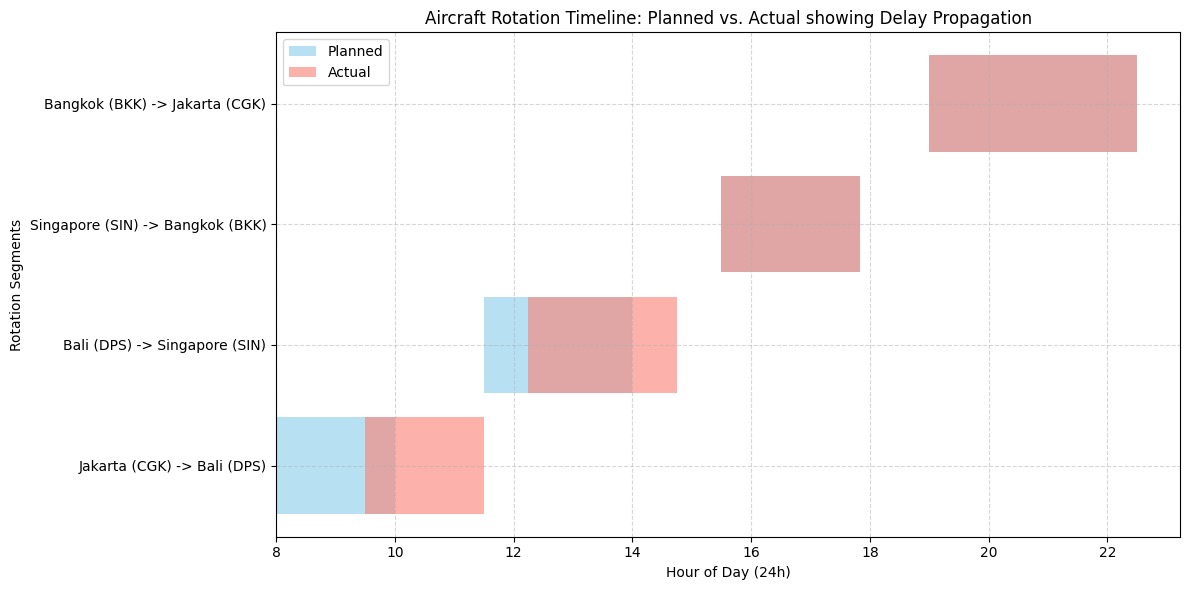

In [ ]:
# Visualize the schedule impact using a horizontal timeline chart
fig, ax = plt.subplots(figsize=(12, 6))

for idx, row in sim_df.iterrows():
    # Plot Scheduled blocks in Green
    ax.barh(row['route'], (row['sched_arr'] - row['sched_dep']).total_seconds() / 3600,
            left=row['sched_dep'].hour + row['sched_dep'].minute / 60,
            color='skyblue', alpha=0.6, label='Planned' if idx == 0 else "")

    # Plot Actual blocks in Red
    ax.barh(row['route'], (row['act_arr'] - row['act_dep']).total_seconds() / 3600,
            left=row['act_dep'].hour + row['act_dep'].minute / 60,
            color='salmon', alpha=0.6, label='Actual' if idx == 0 else "")

ax.set_xlabel('Hour of Day (24h)')
ax.set_ylabel('Rotation Segments')
ax.set_title('Aircraft Rotation Timeline: Planned vs. Actual showing Delay Propagation')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

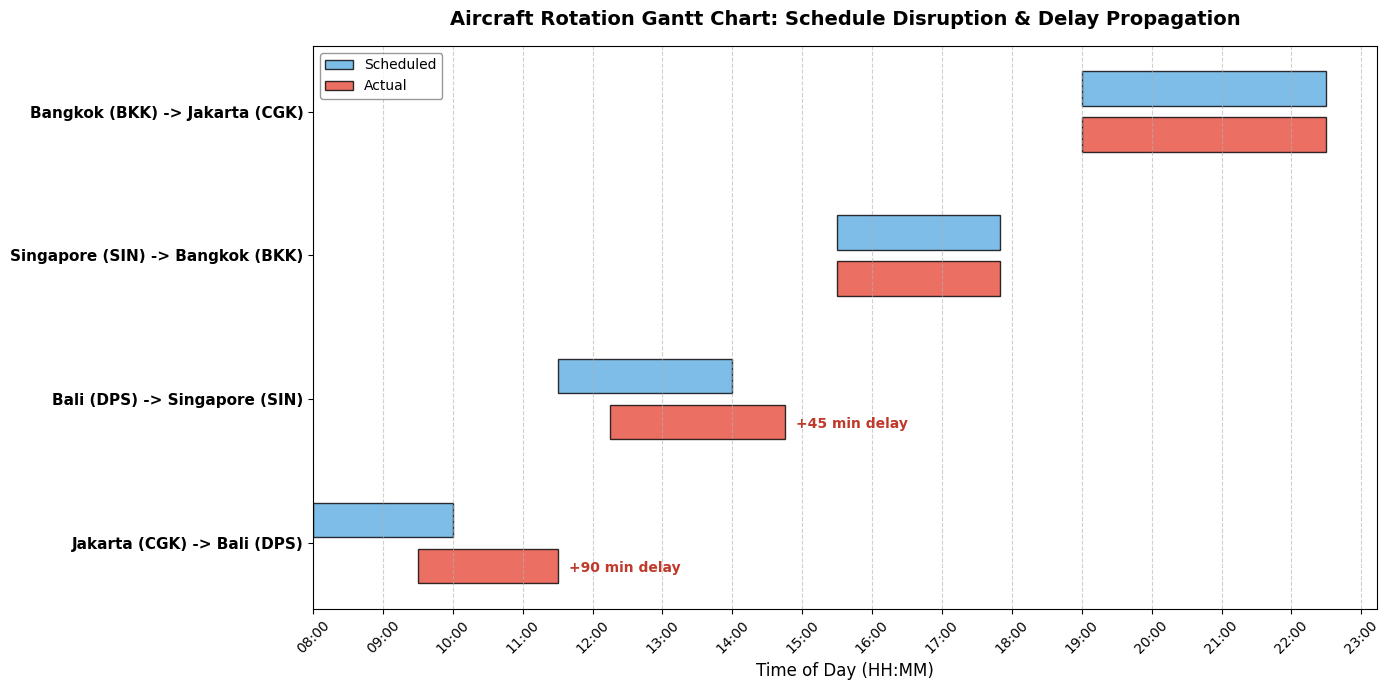

In [ ]:
import matplotlib.dates as mdates

# Configure Gantt Chart data
fig, ax = plt.subplots(figsize=(14, 7))

y_ticks = []
y_labels = []

for idx, row in sim_df.iterrows():
    # Y positions for Scheduled and Actual bars to keep them distinct
    y_sched = idx * 2.5 + 0.4
    y_act = idx * 2.5 - 0.4

    # Scheduled Bar
    ax.barh(y_sched, row['sched_arr'] - row['sched_dep'], left=row['sched_dep'],
            height=0.6, color='#5DADE2', edgecolor='black', alpha=0.8,
            label='Scheduled' if idx == 0 else "")

    # Actual Bar
    ax.barh(y_act, row['act_arr'] - row['act_dep'], left=row['act_dep'],
            height=0.6, color='#E74C3C', edgecolor='black', alpha=0.8,
            label='Actual' if idx == 0 else "")

    # Add text labels for delay amount on actual bar if delay exists
    if row['arr_delay_mins'] > 0:
        ax.text(row['act_arr'] + timedelta(minutes=10), y_act - 0.1,
                f"+{int(row['arr_delay_mins'])} min delay",
                color='#C0392B', fontweight='bold', fontsize=10)

    y_ticks.append(idx * 2.5)
    y_labels.append(row['route'])

# Formatting axes
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=11, fontweight='bold')
ax.set_xlabel('Time of Day (HH:MM)', fontsize=12)
ax.set_title('Aircraft Rotation Gantt Chart: Schedule Disruption & Delay Propagation', fontsize=14, fontweight='bold', pad=15)

# Set X-axis formatter to show hours and minutes nicely
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)

# Grid and Legend
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='gray')

plt.tight_layout()
plt.show()

### Bar Chart Comparing The Scheduled with Actual Departure Delay
Next one, we will create a bar chart comparing the scheduled with actual departure delay.
- The green bars are all at 0 minutes as our original baseline schedule plans for zero disruptions.
- The red bars highlight the actual delay propagated at each departure airport.

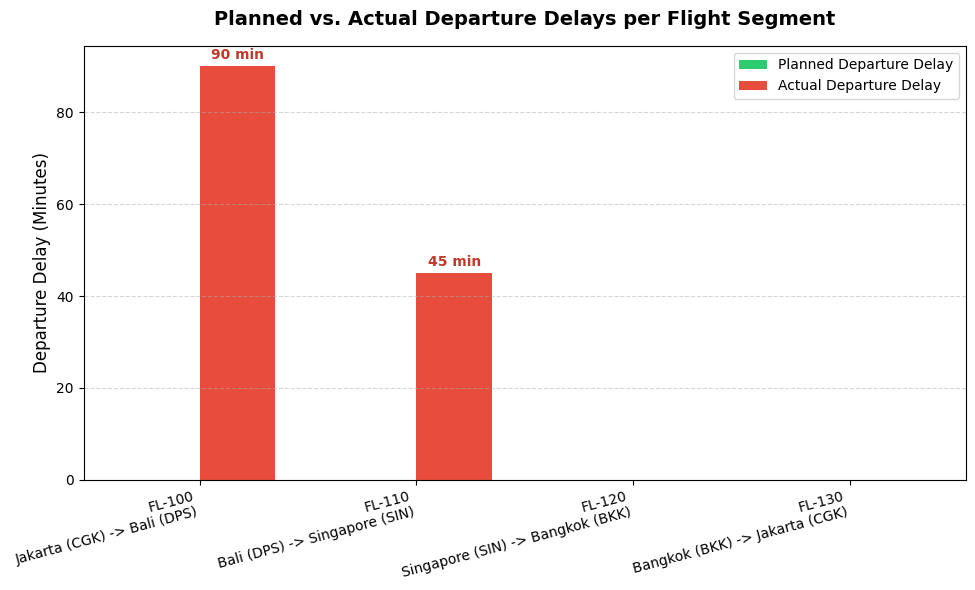

In [ ]:
# Bar chart comparing planned delay (0 mins) with actual departure delays
fig, ax = plt.subplots(figsize=(10, 6))

flights = sim_df['flight_num'] + '\n' + sim_df['route']
actual_delays = sim_df['dep_delay_mins']
planned_delays = [0] * len(sim_df)  # Schedule plan assumes 0 delay

x = np.arange(len(flights))
width = 0.35

# Create side-by-side bars
rects1 = ax.bar(x - width/2, planned_delays, width, label='Planned Departure Delay', color='#2ECC71')
rects2 = ax.bar(x + width/2, actual_delays, width, label='Actual Departure Delay', color='#E74C3C')

ax.set_ylabel('Departure Delay (Minutes)', fontsize=12)
ax.set_title('Planned vs. Actual Departure Delays per Flight Segment', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(flights, rotation=15, ha='right', fontsize=10)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of actual delay bars
for rect in rects2:
    height = rect.get_height()
    if height > 0:
        ax.annotate(f'{int(height)} min',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', color='#C0392B')

plt.tight_layout()
plt.show()